**Previsione dell'affidabilità creditizia per il rilascio della carta di credito** \

Sei stato assunto dalla Pro National Bank come data scientist, e il tuo primo incarico consiste nel realizzare un modello in grado di stimare l'affidabilità creditizia dei clienti, al fine di aiutare il team dedicato a comprendere se accettare o meno la richiesta per il rilascio della carta di credito. \

Il file credit_scoring.csv contiene le informazioni dei correntisti che hanno richiesto l’apertura di una linea di credito. \

ID: numero identificativo del cliente \
CODE_GENDER: sesso del cliente \
FLAGOWNCAR: indicatore del possesso di un'automobile \
FLAGOWNREALTY: indicatore del possesso di una casa \
CNT_CHILDREN: numero di figli \
AMTINCOMETOTAL: reddito annuale \
NAMEINCOMETYPE: tipo di reddito \
NAMEEDUCATIONTYPE: livello di educazione \
NAMEFAMILYSTATUS: stato civile \
NAMEHOUSINGTYPE: tipo di abitazione \
DAYS_BIRTH: numero di giorni trascorsi dalla nascita \
DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato) \
FLAG_MOBIL: indicatore della presenza di un numero di cellulare \
FLAGWORKPHONE: indicatore della presenza di un numero di telefono di lavoro \
FLAG_PHONE: indicatore della presenza di un numero di telefono \
FLAG_EMAIL: indicatore della presenza di un indirizzo email \
OCCUPATION_TYPE: tipo di occupazione \
CNTFAMMEMBERS: numero di familiari \
**TARGET: variabile che vale 1 se il cliente ha una elevata affidabilità**
creditizia (pagamento costante delle rate), 0 altrimenti. \

Obiettivo\
Devi realizzare un modello che preveda il target dato, ovvero la variabile TARGET che indica se il cliente ha una buona affidabilità creditizia. \

Punto bonus \
Se ad un cliente viene negata la carta di credito, il team deve essere in grado di fornirgli una motivazione. Questo significa che il tuo modello deve fornire delle indicazioni facilmente interpretabili. \

In [ ]:
pip install category_encoders

In [ ]:
from category_encoders import LeaveOneOutEncoder,CountEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler,OrdinalEncoder, PowerTransformer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import ks_2samp, chi2_contingency, mannwhitneyu, skew, kurtosis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve,f1_score,accuracy_score,precision_score,recall_score
from imblearn.over_sampling import SMOTE

### Caricamento Dati e Analisi Esplorativa (EDA)

In [ ]:
df = pd.read_csv('/content/credit_scoring.csv')

In [ ]:
df.shape

(338427, 19)

In [ ]:
df.head().T

,0,1,2,3,4
ID,5008804,5008805,5008806,5008808,5008809
CODE_GENDER,M,M,M,F,F
FLAG_OWN_CAR,Y,Y,Y,N,N
FLAG_OWN_REALTY,Y,Y,Y,Y,Y
CNT_CHILDREN,0,0,0,0,0
AMT_INCOME_TOTAL,424380.57,421593.52,110958.51,267497.96,263419.09
NAME_INCOME_TYPE,Working,Working,Working,Commercial associate,Commercial associate
NAME_EDUCATION_TYPE,Higher education,Higher education,Secondary / secondary special,Secondary / secondary special,Secondary / secondary special
NAME_FAMILY_STATUS,Civil marriage,Civil marriage,Married,Single / not married,Single / not married
NAME_HOUSING_TYPE,Rented apartment,Rented apartment,House / apartment,House / apartment,House / apartment


### Verifica la tipologia di ogni variabile

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338427 entries, 0 to 338426
Data columns (total 19 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   338427 non-null  int64  
 1   CODE_GENDER          338427 non-null  object 
 2   FLAG_OWN_CAR         338427 non-null  object 
 3   FLAG_OWN_REALTY      338427 non-null  object 
 4   CNT_CHILDREN         338427 non-null  int64  
 5   AMT_INCOME_TOTAL     338427 non-null  float64
 6   NAME_INCOME_TYPE     338427 non-null  object 
 7   NAME_EDUCATION_TYPE  338427 non-null  object 
 8   NAME_FAMILY_STATUS   338426 non-null  object 
 9   NAME_HOUSING_TYPE    338426 non-null  object 
 10  DAYS_BIRTH           338426 non-null  float64
 11  DAYS_EMPLOYED        338426 non-null  float64
 12  FLAG_MOBIL           338426 non-null  float64
 13  FLAG_WORK_PHONE      338426 non-null  float64
 14  FLAG_PHONE           338426 non-null  float64
 15  FLAG_EMAIL       

## Analisi duplicati

In [ ]:
df.duplicated().sum()

np.int64(0)

### Analisi dei valori mancanti

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          1
NAME_HOUSING_TYPE           1
DAYS_BIRTH                  1
DAYS_EMPLOYED               1
FLAG_MOBIL                  1
FLAG_WORK_PHONE             1
FLAG_PHONE                  1
FLAG_EMAIL                  1
OCCUPATION_TYPE        103342
CNT_FAM_MEMBERS             1
TARGET                      0
dtype: int64


<Axes: >

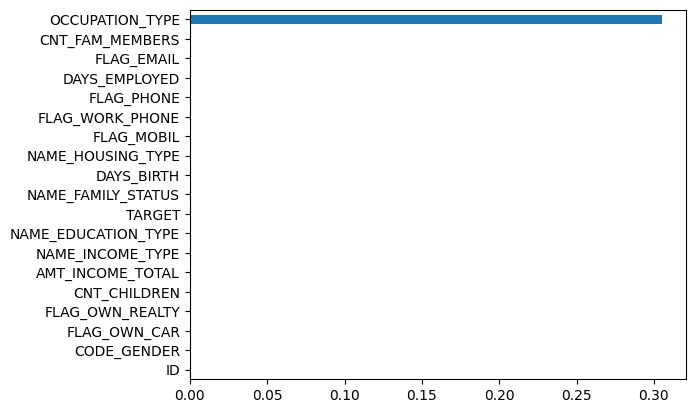

In [ ]:
missing_perc = df.isna().sum()/df.shape[0]
missing_perc.sort_values().plot(kind='barh')

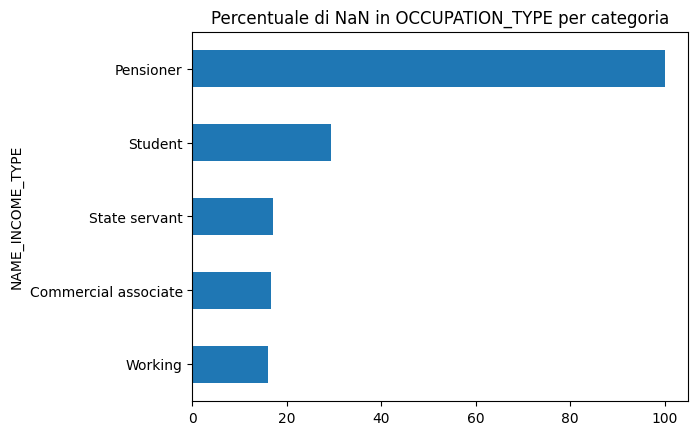

In [ ]:
# Calcola la percentuale di NaN in OCCUPATION_TYPE per ogni categoria di reddito
(df.groupby('NAME_INCOME_TYPE')['OCCUPATION_TYPE']
   .apply(lambda x: x.isna().mean() * 100)
   .sort_values()
   .plot(kind='barh', title='Percentuale di NaN in OCCUPATION_TYPE per categoria'))
plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,338427.0,5.821200e+06,451770.363803,5008804.00,5439601.50,5878907.00,6140206.500,6841875.00
CNT_CHILDREN,338427.0,4.289345e-01,0.727990,0.00,0.00,0.00,1.000,19.00
AMT_INCOME_TOTAL,338427.0,1.876685e+05,110786.279376,25548.98,121229.95,162855.26,225208.155,7071015.83
DAYS_BIRTH,338426.0,-1.599821e+04,4193.088539,-26636.00,-19467.00,-15623.00,-12516.250,-7566.00
DAYS_EMPLOYED,338426.0,6.023453e+04,138522.923248,-17973.00,-3116.00,-1483.00,-378.000,396498.00
FLAG_MOBIL,338426.0,1.000000e+00,0.000000,1.00,1.00,1.00,1.000,1.00
FLAG_WORK_PHONE,338426.0,2.113786e-01,0.408287,0.00,0.00,0.00,0.000,1.00
FLAG_PHONE,338426.0,2.933019e-01,0.455276,0.00,0.00,0.00,1.000,1.00
FLAG_EMAIL,338426.0,1.051810e-01,0.306787,0.00,0.00,0.00,0.000,1.00
CNT_FAM_MEMBERS,338426.0,2.197228e+00,0.899570,1.00,2.00,2.00,3.000,20.00


Le variabili FLAG_MOBIL, FLAG_WORK_PHONE, FLAG_PHONE,FLAG_EMAIL verranno poi considerate come numeriche_categoriche dato che si presentano nella forma [0,1].
FLAG_MOBIL è una costante quindi non informativa, la possiamo rimuovere dal dataset.

Per AMT_INCOME_TOTAL occorrerà una trasformazione visto che è diversi ordini di grandezza più grande del resto.

DAYS_BIRTH ha un min e un max negativi, la renderò positiva e poi la trasformerò in anni per facilità di comprensione.

DAYS_EMPLOYED risulta ha valori molto strani, anche trasformando in anni non sembra avere un reale significato fisico. Necessita di un analisi più approfondita.


In [ ]:
df.describe(include='object')

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
count,338427,338427,338427,338427,338427,338426,338426,235085
unique,2,2,2,5,6,5,6,18
top,F,N,Y,Working,Secondary / secondary special,Married,House / apartment,Laborers
freq,227916,213196,231307,174366,232568,231494,304410,60146


###Analisi del target

<Axes: xlabel='TARGET', ylabel='proportion'>

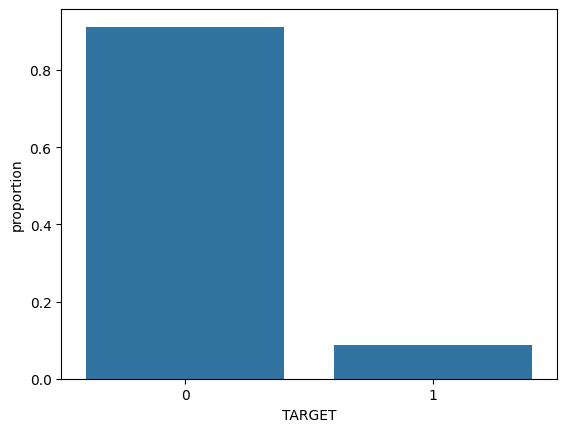

In [ ]:
sns.countplot(data=df,x="TARGET",stat = "proportion")

In [ ]:
df["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
0,0.912176
1,0.087824


 ### La variabile risposta si presenta molto sbilanciata, sarà necessario adottare oversampling con lo SMOTE oppure bilanciare il peso delle classi durante l'addestramento.  

 ### Per entrare meglio nella logica di business credo che la descrizione fornita per il valore del target risulti invertita. Considererò quindi 0=elevata affidabilità 1=bassa affidabilità.

# Analisi variabili quantitative

<Axes: xlabel='DAYS_EMPLOYED'>

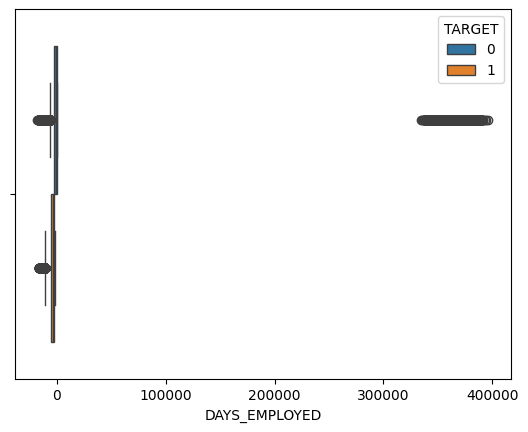

In [ ]:
sns.boxplot(data=df,x='DAYS_EMPLOYED',hue='TARGET')

💡 **INSIGHT** Dalla descrizione presente nelle info del dataset i valori > 0 indica il numero di giorni da quando il cliente è disoccupato.

(-20000.0, 500.0)

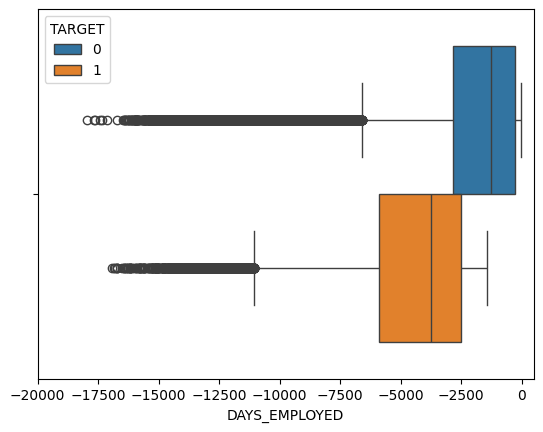

In [ ]:
ax = sns.boxplot(data=df,x='DAYS_EMPLOYED',hue='TARGET')
ax.set_xlim(-20000, 500)

💡 **INSIGHT** Esiste una relazione non banale tra la variabile DAYS_EMPLOYED, considerando solo i lavoratori e la variabile risposta.

(300000.0, 400000.0)

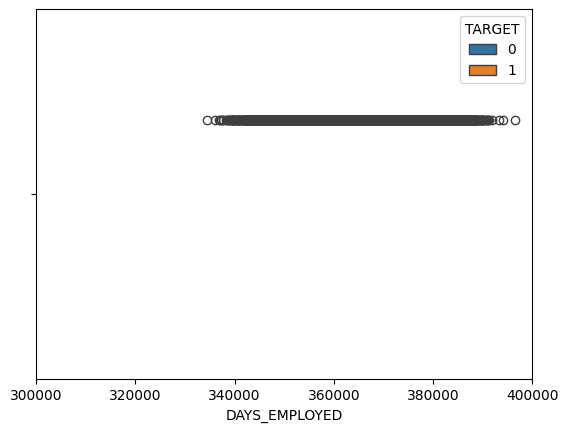

In [ ]:
bx = sns.boxplot(data=df,x='DAYS_EMPLOYED',hue='TARGET')
bx.set_xlim(300000, 400000)

💡 **INSIGHT** Questi valori anomali non verranno scartati, dato il numero molto elevato, ma andranno analizzati per capire se rappresentano una specifica categoria di clienti.

<Axes: >

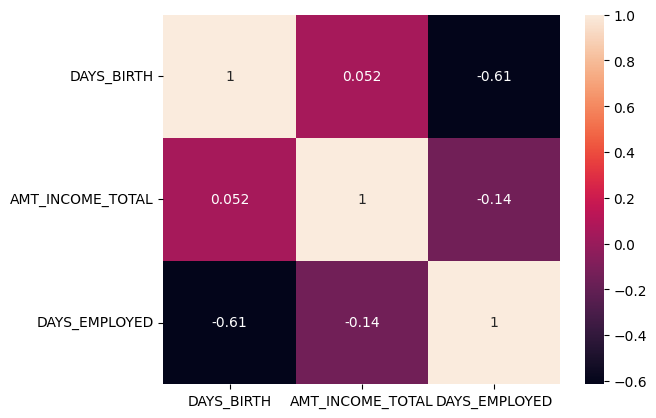

In [ ]:
sns.heatmap(df[['DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'DAYS_EMPLOYED']].corr(),annot=True)

# Prendo un campione casuale di 10.000 righe (o il 5% del dataset) per velocizzare la visualizzazione del pairplot

df_sample = df.sample(n=10000, random_state=42)
💡 Dall'analisi della matrice di correlazione sembra che sia presente una relazione lineare medio forte tra DAYS_EMPLOYED ed DAYS_BIRTH mentre.Non è presente una relazione lineare tra DAYS_EMPLOYED e AMT_INCOME_TOTAL, cioè ad una maggiore anzianità di servizio non è associata ad un income maggiore.

Analizziamo graficamente per cercare di chiarire meglio questi valori.

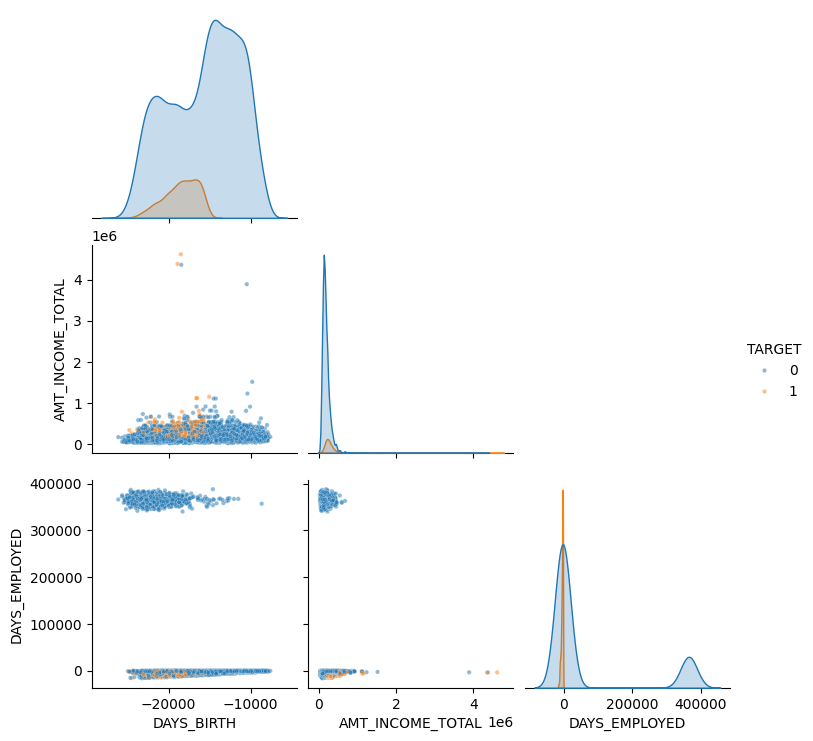

In [ ]:
# Prendo un campione casuale di 10.000 righe per velocizzare la visualizzazione del pairplot

df_sample = df.sample(n=10000, random_state=42)

sns.pairplot(data=df_sample,
             vars=['DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'DAYS_EMPLOYED'],
             hue='TARGET',
             corner=True,
             diag_kind='kde',  # Mostra la densità sulla diagonale
             plot_kws={'alpha': 0.5, 's': 10}) # Trasparenza e dimensione punti

plt.show()

💡 Dall'analisi del pairplot vediamo che in realtà i valori ottenuti dalla matrice di correlazione sono viziati in maniera evidente da tutta una serie di valori di DAY_EMPLOYED (che abbiamo già osservato sopra) che sembrano molto strani, in quanto fisicamente impossibili. Considerando questi valori anomali non è presente nessun tipo di correlazione lineare. Da una prima analisi veloce si nota inoltre come per i valori di DAY_EMPLOYED sopra ad una certa soglia, non ci sono corrispondenze con il TARGET = 1.

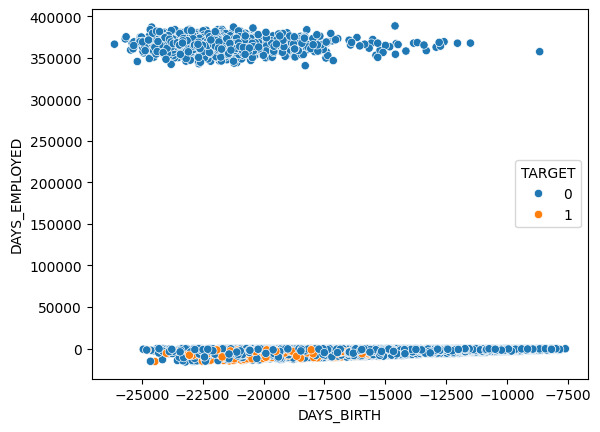

In [ ]:
sns.scatterplot(data=df_sample, x='DAYS_BIRTH', y='DAYS_EMPLOYED', hue='TARGET')
plt.show()

💡Provo a vedere se questa correlazione fittizia è dovuta a questi valori.Dall'analisi precedente sui missing values, dove ho analizzato, essere associati per la maggior parte alla categoria dei pensionati, anche in questo caso questi valori potrebbero essere legati a quella categoria.

<Axes: >

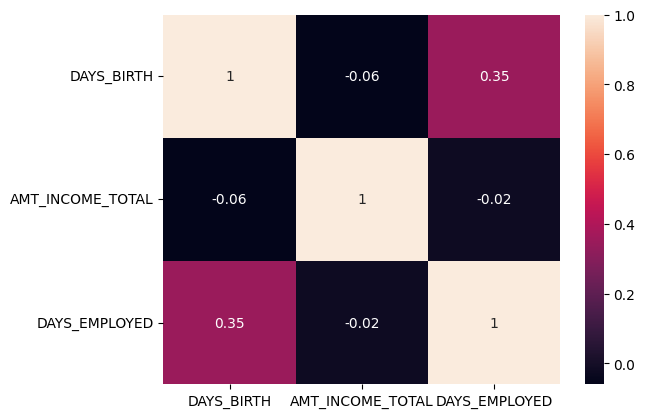

In [ ]:
# Filtriamo: solo lavoratori reali
lavoratori_df = df[df['DAYS_EMPLOYED'] < 0]

sns.heatmap(lavoratori_df[['DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'DAYS_EMPLOYED']].corr(),annot=True)

💡 Considerando solo i lavoratori la forza della correlazione lineare tra DAYS_EMPLOYED e DAYS_BIRTH si dimezza

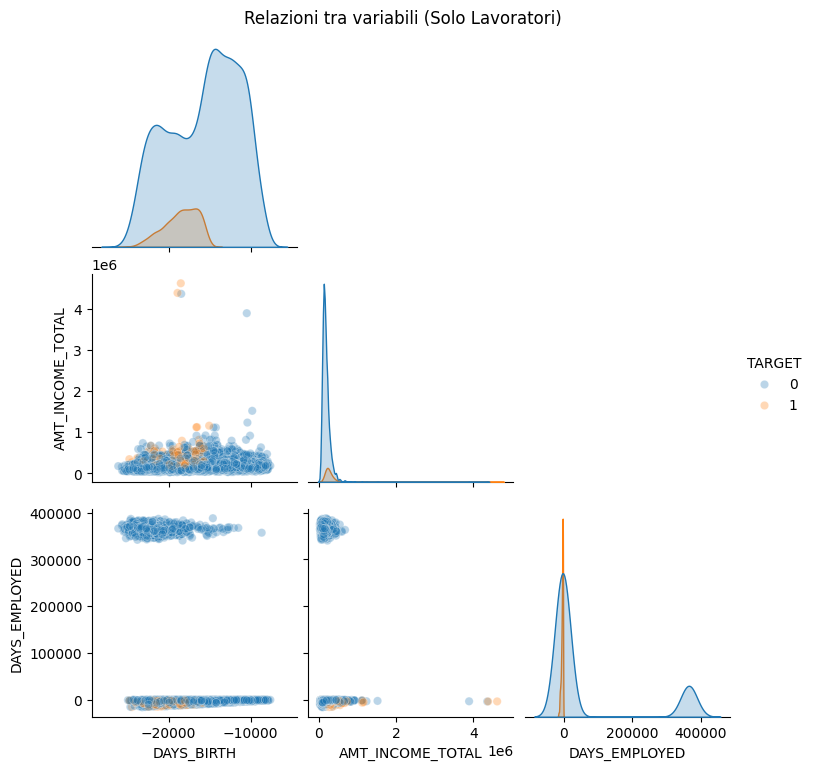

In [ ]:
# Prendo un campione casuale di 10.000 righe per velocizzare la visualizzazione del pairplot

df_sample = df.sample(n=10000, random_state=42)

sns.pairplot(data=df_sample,
             vars=['DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'DAYS_EMPLOYED'],
             hue='TARGET',
             corner=True,
             diag_kind='kde',
             kind='scatter',
             plot_kws={'alpha': 0.3}) # Trasparenza per vedere la densità dei punti

plt.suptitle("Relazioni tra variabili (Solo Lavoratori)", y=1.02)
plt.show()

<Axes: xlabel='DAYS_BIRTH'>

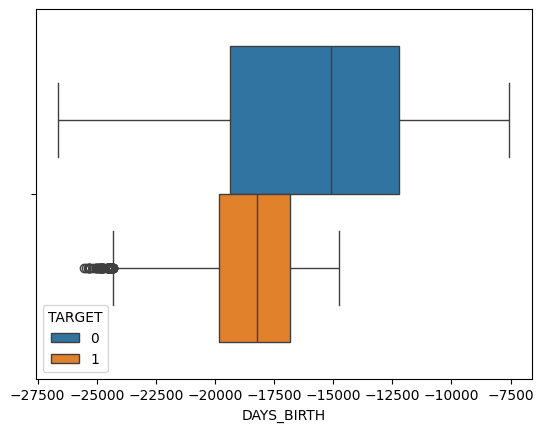

In [ ]:
sns.boxplot(df,x='DAYS_BIRTH',hue='TARGET')

💡  La distribuzione della variabile cambia in maniera significativa al variare del target, il che indica una possibile relazione non banale tra AGE ed il TARGET.
Osservo un'anomalia rispetto alle mie assunzioni di base in quanto ad una maggiore età sembra assosociata una minore affidabilità creditizia.

<Axes: xlabel='AMT_INCOME_TOTAL'>

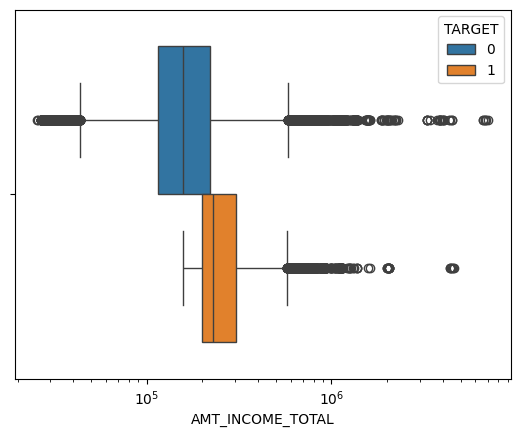

In [ ]:
sns.boxplot(df,x='AMT_INCOME_TOTAL',hue='TARGET',log_scale=10)

💡  La distribuzione della variabile cambia in maniera significativa al variare del target, il che indica una possibile relazione non banale tra AMT_INCOME_TOTAL ed il TARGET.

<Axes: xlabel='DAYS_EMPLOYED', ylabel='Count'>

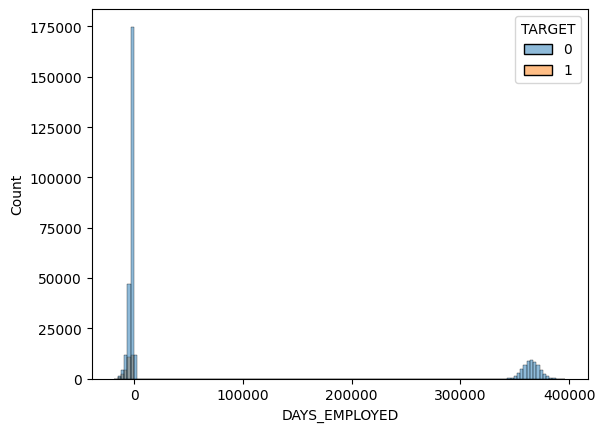

In [ ]:
sns.histplot(df,x="DAYS_EMPLOYED",bins="rice",hue='TARGET')

Dalla descrizione delle variabili DAYS_EMPLOYED: numero di giorni trascorsi dalla data di assunzione (se positivo, indica il numero di giorni da quando è disoccupato)

💡  La distribuzione della variabile DAYS_EMPLOYED risulta spaccata in due con un'elevatissimo numero di valori presenti al di sopra di una certa soglia.
Partendo dall'analisi precedente sui valori mancanti, dove la maggior parte di questi valori erano associati alla categoria "pensioner", per questa categoria il sistema potrebbe aver assegnato un valore elevatissimo, fisicamente impossibile, per identificarli.

Dalla conoscenza del dominio possiamo supporre che questa modalità di classificare i pensionati con un numero di giorni prossimo ai 1000 anni sia uno standard di sistema.

<Axes: xlabel='DAYS_EMPLOYED', ylabel='Count'>

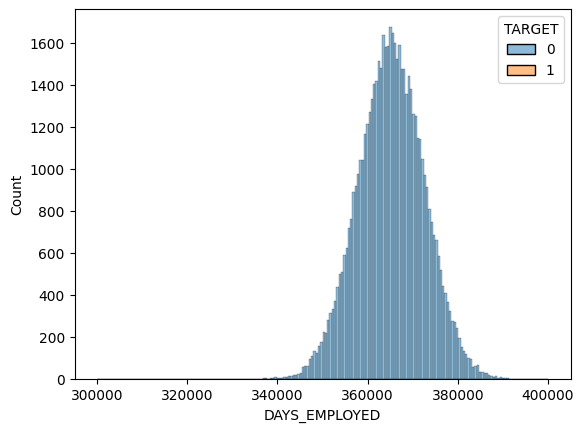

In [ ]:
sns.histplot(df, x="DAYS_EMPLOYED", hue='TARGET', binrange=(300000, 400000))

💡 Dall'analisi grafica risulta subito evidente come in questo range della distribuzione di DAYS_EMPLOYED ci sia una relazione fortissima con il target in quanto non sono presenti record associati alla variabile TARGET = 1. Quindi già possiamo capire come sia presente una relazione non banale tra DAYS_EMPLOYED ed il TARGET.

Per la creazione del modello potrebbe essere utile andare a ragionare su valori soglia per effettuare la classificazione. La logica utilizzata dal sistema, se in una prima fase può generare confusione, in realtà, vista la forte relazione tra i valori sopra ad una certa soglia ed il target, possiamo già intuire che sarà di grande aiuto nella classificazione.


In [ ]:
filtro1 = (df['TARGET'] == 1) & (df['NAME_INCOME_TYPE'] == 'Pensioner')
risultato1 = df[filtro1]

print(len(risultato1))

0


In [ ]:
filtro2 = (df['TARGET'] == 0) & (df['NAME_INCOME_TYPE'] == 'Pensioner')
risultato2 = df[filtro2]

print(len(risultato2))

57841


In [ ]:
filtro3 = df['NAME_INCOME_TYPE'] == 'Pensioner'
risultato3 = df[filtro3]

print(len(risultato3))

57841


In [ ]:
filtro4 = (df['DAYS_EMPLOYED'] > 0) & (df['NAME_INCOME_TYPE'] == 'Pensioner')
risultato4 = df[filtro4]

print(len(risultato4))

57841


💡L'analisi numerica ci conferma l'intuizione fatta dall'analisi grafica, quindi esiste una forte relazione tra la categoria "Pensioner" ed il target.

Quindi la categoria dei pensionati possiamo già intuire che sarà importante per il modello.
La sua distribuzione non lineare però potrà mettere in crisi modelli dei modelli lineari.

<Axes: xlabel='DAYS_EMPLOYED', ylabel='Count'>

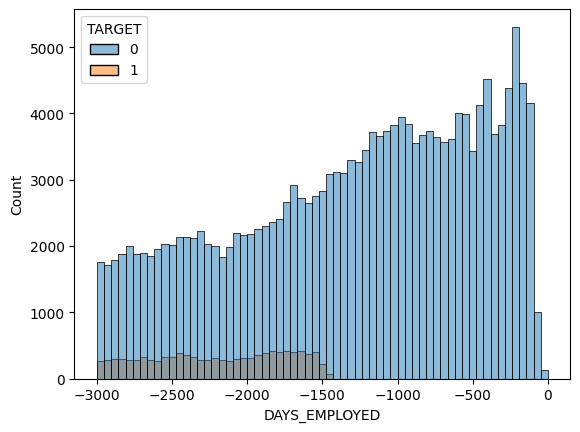

In [ ]:
sns.histplot(df, x="DAYS_EMPLOYED", hue='TARGET', binrange=(-3000, 0))

💡Analizzando la parte della distribuzione relativa ai "Non Pensionati" possiamo vedere come anche qui è presente una forte relazione tra la variabile ed il TARGET. In particolare, ad di sotto di una certa soglia di giorni trascorsi dalla data di assunzione (valori più positivi), una fascia di utenti risulta avere un'alta affidabilità creditizia.

In [ ]:
pensionati = df['DAYS_EMPLOYED'] > 0
pensionati.value_counts()

,count
DAYS_EMPLOYED,
False,280586
True,57841


In [ ]:
df[df['DAYS_EMPLOYED'] > 20000]['NAME_INCOME_TYPE'].value_counts()

,count
NAME_INCOME_TYPE,
Pensioner,57841


(-20000.0, 500.0)

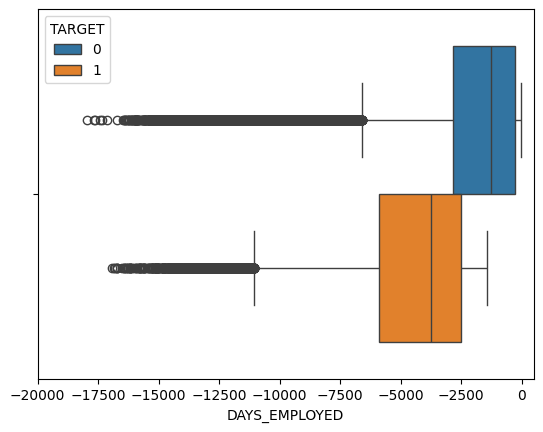

In [ ]:
ax = sns.boxplot(data=df, x='DAYS_EMPLOYED', hue='TARGET')
ax.set_xlim(-20000, 500)

💡 Come nel caso della variabile DAYS_BIRTH, anche per la variabile DAYS_EMPLOYED si osserva come ad un maggior numero di giorni trascorsi dalla data di assunzione sia associata una minore affidabilità creditizia.

# Analisi Variabili Categoriche e Ordinali

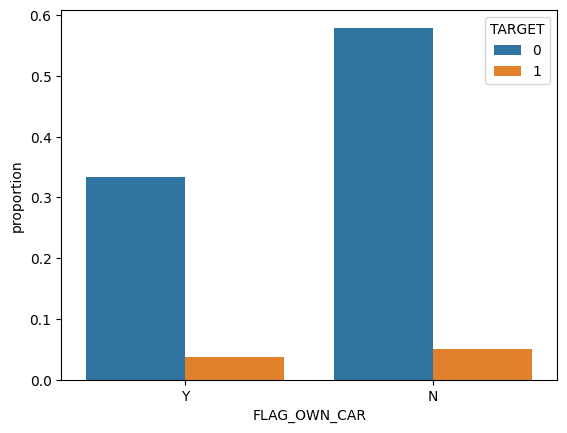

In [ ]:
sns.countplot(data=df, x='FLAG_OWN_CAR', hue='TARGET', stat='proportion')
plt.show()

💡 Non sembra essere presente una relazione significativa tra le modalità della variabile ed il target.

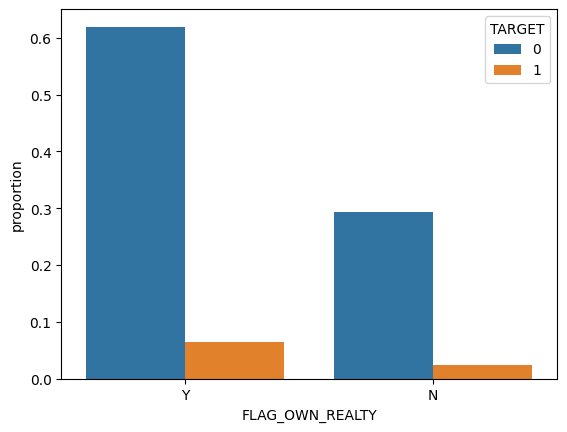

In [ ]:
sns.countplot(data=df, x='FLAG_OWN_REALTY', hue='TARGET', stat='proportion')
plt.show()

💡 Non sembra essere presente una relazione significativa tra le modalità della variabile ed il target.

In [ ]:
df['NAME_INCOME_TYPE'].unique()

array(['Working', 'Commercial associate', 'Pensioner', 'State servant',
       'Student'], dtype=object)

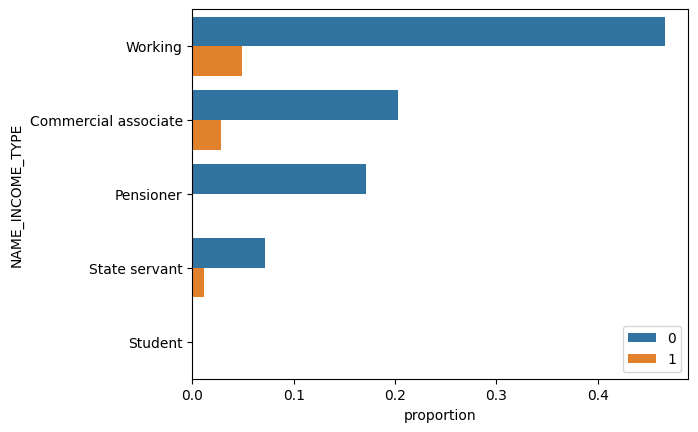

In [ ]:
sns.countplot(data=df, y='NAME_INCOME_TYPE', hue='TARGET', stat='proportion')
plt.legend(loc='lower right')
plt.show()

💡 La categoria pensioner risulta quella più affidabile. La categoria degli studenti invece non sembra rappresentata.

In [ ]:
num_studenti = df['NAME_INCOME_TYPE'] == 'Student'
print(num_studenti.value_counts())

NAME_INCOME_TYPE
False    338410
True         17
Name: count, dtype: int64


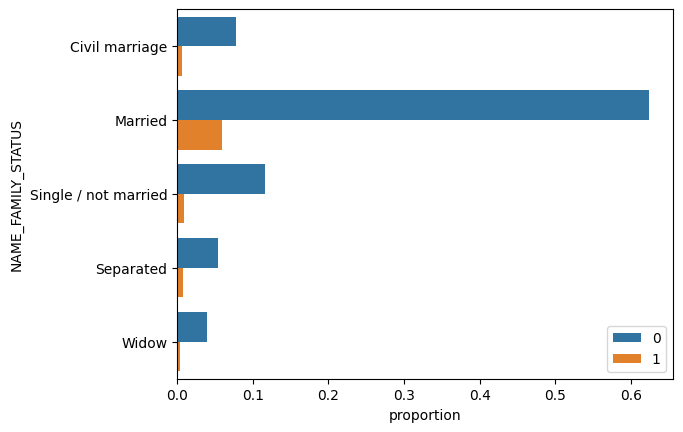

In [ ]:
sns.countplot(data=df, y='NAME_FAMILY_STATUS', hue='TARGET', stat='proportion')
plt.legend(loc='lower right')
plt.show()

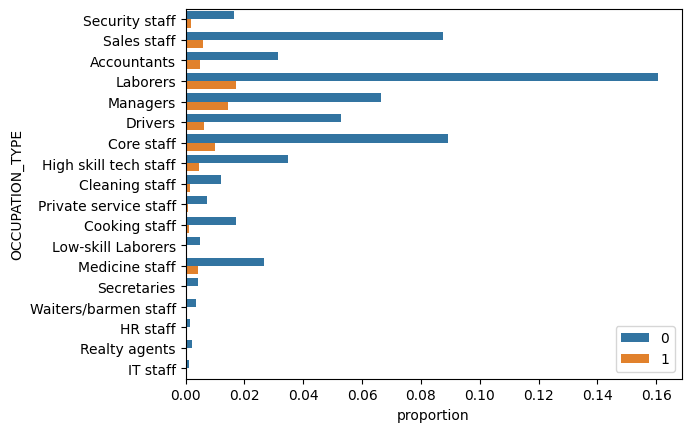

In [ ]:
sns.countplot(data=df, y='OCCUPATION_TYPE', hue='TARGET', stat='proportion')
plt.legend(loc='lower right')
plt.show()

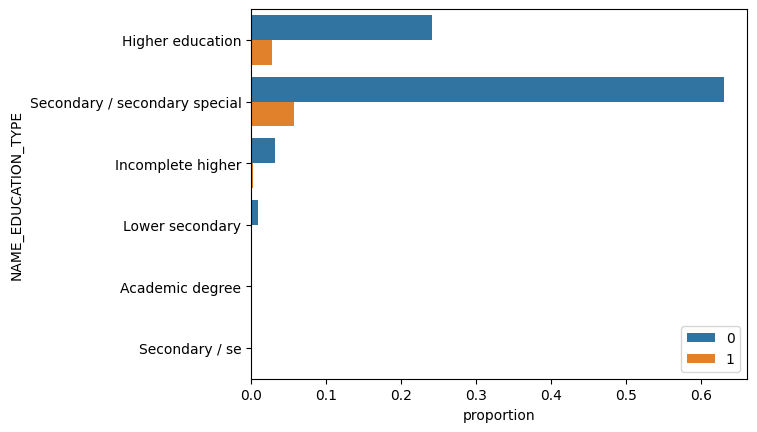

In [ ]:
sns.countplot(data=df, y='NAME_EDUCATION_TYPE', hue='TARGET', stat='proportion')
plt.legend(loc='lower right')
plt.show()

💡 Dall'analisi di NAME_EDUCATION_TYPE a prima vista sembra essere presente una gerarchia anomalo dove una maggiore istruzione sembra essere legata ad una minore affidabilità creditizia.

In [ ]:
pensioner_education = df.groupby('NAME_EDUCATION_TYPE')['NAME_INCOME_TYPE'].value_counts().sort_values(ascending=False)
print(pensioner_education)

NAME_EDUCATION_TYPE            NAME_INCOME_TYPE    
Secondary / secondary special  Working                 124996
                               Pensioner                46449
                               Commercial associate     46305
Higher education               Working                  41503
                               Commercial associate     27744
Secondary / secondary special  State servant            14814
Higher education               State servant            12193
                               Pensioner                 9611
Incomplete higher              Working                   6305
                               Commercial associate      3575
Lower secondary                Working                   1443
                               Pensioner                 1215
Incomplete higher              State servant              955
                               Pensioner                  550
Lower secondary                Commercial associate       409
Academic degree   

💡 Anche in questo caso la categoria dei Pensioner, che pesa molto sul numero di clienti complessivo, tende a distorcere la nostra prima impressione spingendo il conteggio del TARGET = 0. Notiamo come nella categoria Higher education il numero di pensionati sia molto più piccolo.

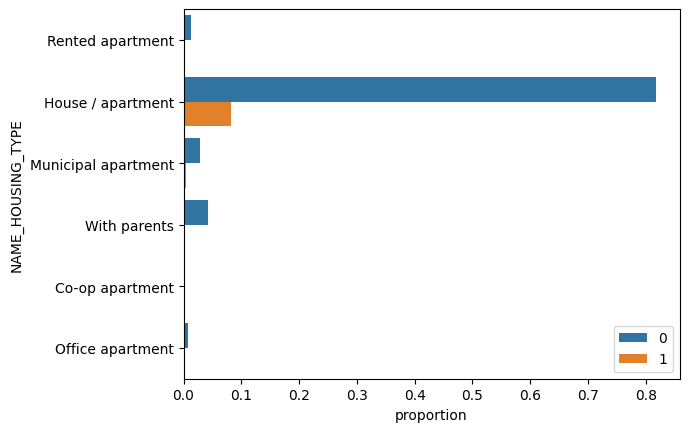

In [ ]:
sns.countplot(data=df, y='NAME_HOUSING_TYPE', hue='TARGET', stat='proportion')
plt.legend(loc='lower right')
plt.show()

# Pre-processing e codifica

In [ ]:
df_prep = df.copy()

In [ ]:
df_prep['AGE'] = abs(df_prep['DAYS_BIRTH']/365) #creazione della colonna anni per migliorare la comprensione

Per la gestione dei pensionati dato che la variabile DAYS_EMPLOYED, come abbiamo visto nel pairplot, creerà delle allucinazioni nei modelli lineari, andrò a creare una flag dedicata e una successiva imputazione = 0.



## Tutta questa fase viene eseguita esclusivamente per provare un modello baseline lineare. Con modelli non lineri, come ad esempio gli alberi decisionali, la distribuzione cosi anomala della variabile DAYS_EMPLOYED avrebbe semplicemente permesso al modello di effetture un 'taglio'.

In [ ]:
#Creo la flag is_pensioner altrimenti quando vado ad imputare i pensionati = 0 rischierei di considerare i pensionati alla pari dei neo-assunti
df_prep['IS_PENSIONER'] = (df_prep['DAYS_EMPLOYED'] > 0).astype(int) #flag per distinguire poi i pensionati
df_prep['DAYS_EMPLOYED_CLEAN'] = df_prep['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else abs(x))
df_prep['YEARS_EMPLOYED'] = abs(df_prep['DAYS_EMPLOYED_CLEAN']/365) #anni di lavoro, impostati positivi per migliore comprensione

In [ ]:
# Gestione Pensionati
df_prep.loc[(df_prep['NAME_INCOME_TYPE'] == 'Pensioner') & (df_prep['OCCUPATION_TYPE'].isna()), 'OCCUPATION_TYPE'] = 'Retired'

In [ ]:
# Gestione Studenti
df_prep.loc[(df_prep['NAME_INCOME_TYPE'] == 'Student') & (df_prep['OCCUPATION_TYPE'].isna()), 'OCCUPATION_TYPE'] = 'Full-time Student'

In [ ]:
# Gestione degli altri NaN (Working, Commercial Associate, ecc.)
# Per le altre categorie dove il tipo di entrata è "dichiarato" ma l'occupazione manca
df_prep['OCCUPATION_TYPE'] = df_prep['OCCUPATION_TYPE'].fillna('Unknown')

In [ ]:
print("\nMissing Values after pre-processing:")
print(df_prep.isnull().sum())


Missing Values after pre-processing:
ID                     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     1
NAME_HOUSING_TYPE      1
DAYS_BIRTH             1
DAYS_EMPLOYED          1
FLAG_MOBIL             1
FLAG_WORK_PHONE        1
FLAG_PHONE             1
FLAG_EMAIL             1
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        1
TARGET                 0
AGE                    1
IS_PENSIONER           0
DAYS_EMPLOYED_CLEAN    1
YEARS_EMPLOYED         1
dtype: int64


In [ ]:
df_prep = df_prep.dropna() #Eliminanzione dei NaN rimasti

## Separazione Train/Test

In [ ]:
df_model = df_prep.drop(['ID','DAYS_BIRTH','DAYS_EMPLOYED','DAYS_EMPLOYED_CLEAN','FLAG_MOBIL'], axis=1)

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338426 entries, 0 to 338425
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   CODE_GENDER          338426 non-null  object 
 1   FLAG_OWN_CAR         338426 non-null  object 
 2   FLAG_OWN_REALTY      338426 non-null  object 
 3   CNT_CHILDREN         338426 non-null  int64  
 4   AMT_INCOME_TOTAL     338426 non-null  float64
 5   NAME_INCOME_TYPE     338426 non-null  object 
 6   NAME_EDUCATION_TYPE  338426 non-null  object 
 7   NAME_FAMILY_STATUS   338426 non-null  object 
 8   NAME_HOUSING_TYPE    338426 non-null  object 
 9   FLAG_WORK_PHONE      338426 non-null  float64
 10  FLAG_PHONE           338426 non-null  float64
 11  FLAG_EMAIL           338426 non-null  float64
 12  OCCUPATION_TYPE      338426 non-null  object 
 13  CNT_FAM_MEMBERS      338426 non-null  float64
 14  TARGET               338426 non-null  int64  
 15  AGE                  3

In [ ]:

X = df_model.drop(['TARGET'], axis=1)

y = df_model['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X: (338426, 17)
Shape of y: (338426,)
Shape of X_train: (270740, 17)
Shape of X_test: (67686, 17)
Shape of y_train: (270740,)
Shape of y_test: (67686,)



# Pipeline

In [ ]:
#variabili numeriche sulle quali applichiamo solo la standardizzazione
numerical_features = ['CNT_CHILDREN', 'AGE', 'YEARS_EMPLOYED', 'CNT_FAM_MEMBERS']

#variabili numeriche sulle quali applichiamo una trasformazione di potenza e la standardizzazione
numerical_features_pot = ['AMT_INCOME_TOTAL']

# Colonna binaria ma testuale, richiede OHE
ohe_categorical_features = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

# Colonna già in 0/1, ma che beneficia dello scaling per la regolarizzazione
scaled_binary_features = ['FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL','IS_PENSIONER']

#Colonne categoriche alle quale applichiamo il frequency encoding senza aumentare eccessivamente il numero di feature con ohe
freq_enc_categorical_features = ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE','OCCUPATION_TYPE']

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        # Pipeline per colonne numeriche che necessitano di StandardScaler
        ('num_scale', StandardScaler(), numerical_features),

        ('num_pot_scale',make_pipeline(PowerTransformer(), StandardScaler()), numerical_features_pot),

        # Pipeline per colonne binarie testuali (necessitano di OHE)
        ('ohe_bin', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), ohe_categorical_features),

        # Pipeline per colonne numeriche già 0/1: SOLO Standardizzazione
        ('scaled_bin', StandardScaler(), scaled_binary_features),

        # Frequency encoding
        ('freq_enc', CountEncoder(normalize=True), freq_enc_categorical_features)

    ],
    remainder='passthrough' # Mantiene le colonne non specificate che poi rimuoveremo
)

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

print("Shape of transformed X_train:", X_train_transformed.shape)
print("Shape of transformed X_test:", X_test_transformed.shape)

Shape of transformed X_train: (270740, 17)
Shape of transformed X_test: (67686, 17)


## Come baseline utilizzo un modello di regressione logistica.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')

In [ ]:
print("Addestramento del modello di regressione logistica in corso...")
model.fit(X_train_transformed, y_train)

Addestramento del modello di regressione logistica in corso...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:

# Predizioni
y_pred_prob = model.predict_proba(X_test_transformed)[:, 1]
y_pred = model.predict(X_test_transformed)

# Valutazione
print("Accuracy:", roc_auc_score(y_test, y_pred_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.933499051190006
Confusion Matrix:
 [[51726 10016]
 [  604  5340]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.84      0.91     61742
           1       0.35      0.90      0.50      5944

    accuracy                           0.84     67686
   macro avg       0.67      0.87      0.70     67686
weighted avg       0.93      0.84      0.87     67686



## Il classification report verrà analizzato successivamente per fare un con confronto diretto con il modello di random forest.

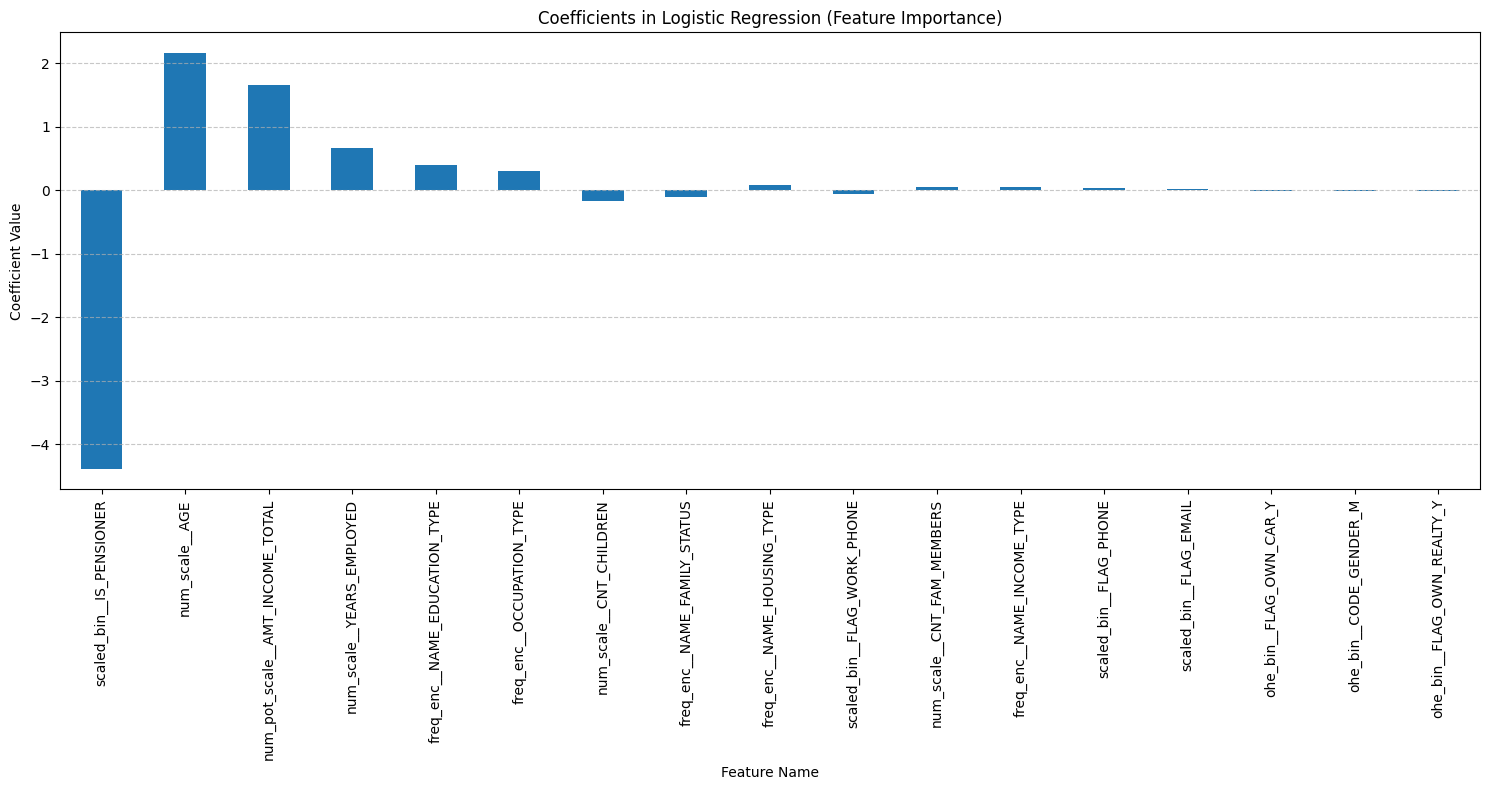

In [ ]:
feature_names_out = preprocessor.get_feature_names_out()

df_model_coef = pd.DataFrame(model.coef_.flatten(), index=feature_names_out, columns=['Coefficient'])

df_model_coef['Absolute_Coefficient'] = df_model_coef['Coefficient'].abs()
df_sorted = df_model_coef.sort_values(by='Absolute_Coefficient', ascending=False)

plt.figure(figsize=(15, 8))
df_sorted['Coefficient'].plot(kind='bar')
plt.title('Coefficients in Logistic Regression (Feature Importance)')
plt.xlabel('Feature Name')
plt.ylabel('Coefficient Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
print(df_sorted)

                                 Coefficient  Absolute_Coefficient
scaled_bin__IS_PENSIONER           -4.381466              4.381466
num_scale__AGE                      2.159341              2.159341
num_pot_scale__AMT_INCOME_TOTAL     1.659719              1.659719
num_scale__YEARS_EMPLOYED           0.672760              0.672760
freq_enc__NAME_EDUCATION_TYPE       0.392617              0.392617
freq_enc__OCCUPATION_TYPE           0.295531              0.295531
num_scale__CNT_CHILDREN            -0.175730              0.175730
freq_enc__NAME_FAMILY_STATUS       -0.102847              0.102847
freq_enc__NAME_HOUSING_TYPE         0.083943              0.083943
scaled_bin__FLAG_WORK_PHONE        -0.065328              0.065328
num_scale__CNT_FAM_MEMBERS          0.056044              0.056044
freq_enc__NAME_INCOME_TYPE          0.054373              0.054373
scaled_bin__FLAG_PHONE              0.031439              0.031439
scaled_bin__FLAG_EMAIL              0.012975              0.01

### **Considerazioni sull'Importanza delle Variabili:**

I coefficienti ci dicono non solo quanto una variabile è importante, ma in che direzione spinge il rischio.
Coefficiente Positivo (+) = Aumenta il Rischio (Default); Negativo (-) = Aumenta la Sicurezza.

*   scaled_bin__IS_PENSIONER (-4.35): È il valore più alto in valore assoluto.Conferma che essere pensionato è il fattore più potente per abbattere il rischio. Il modello dice: "Se sei pensionato, la probabilità di default crolla quasi a zero".

*   num_scale__AGE (+2.18): L'Età è un fattore di Rischio. Sorprendente ma coerente con i dati e con l'EDA. Il segno + indica che all'aumentare dell'età diminuisce l'affidabilità creditizia.

*   num_pot_scale__AMT_INCOME_TOTAL (+1.69): Chi guadagna di più ha una probabilità più alta di essere meno affidabile. Possiamo avanzare l'ipotesi che i clienti meno affidabili qui sono persone benestanti ma magari troppo esposte finanziariamente

*   num_scale__YEARS_EMPLOYED (+0.67). Conferma che i veterani sono più rischiosi dei neo-assunti (forse perchè hanno poco credito?)


## Implementiamo il random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100,
                                  class_weight='balanced',
                                  max_depth=15,
                                  random_state=42,
                                  n_jobs=-1)

In [ ]:
print("Addestramento del Random Forest in corso...")
rf_model.fit(X_train_transformed, y_train)

Addestramento del Random Forest in corso...


RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test_transformed)
y_proba_rf = rf_model.predict_proba(X_test_transformed)[:, 1]

In [ ]:
print("\n--- METRICHE RANDOM FOREST ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nReport di Classificazione:")
print(classification_report(y_test, y_pred_rf))


--- METRICHE RANDOM FOREST ---
ROC-AUC Score: 0.9781
Confusion Matrix:
 [[58772  2970]
 [  116  5828]]

Report di Classificazione:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     61742
           1       0.66      0.98      0.79      5944

    accuracy                           0.95     67686
   macro avg       0.83      0.97      0.88     67686
weighted avg       0.97      0.95      0.96     67686



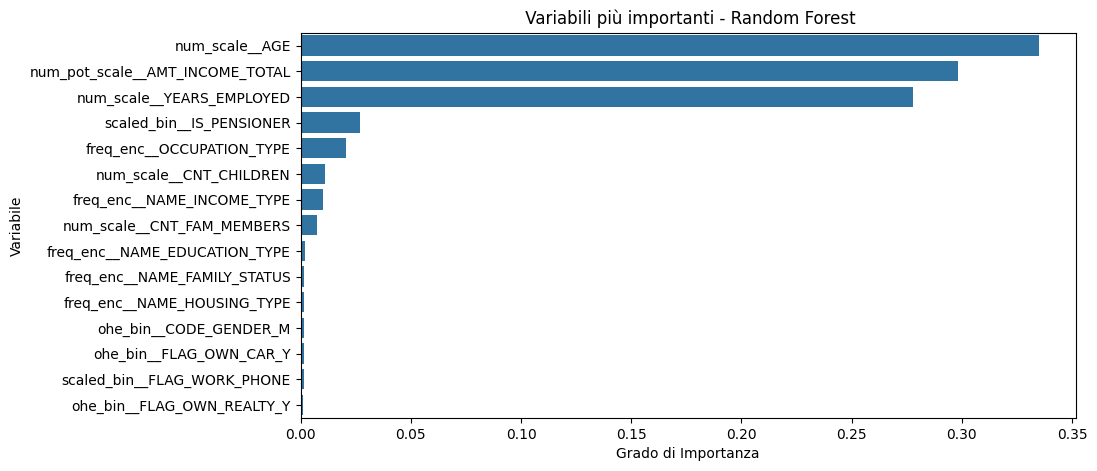

                            Feature  Importance
1                    num_scale__AGE    0.334933
4   num_pot_scale__AMT_INCOME_TOTAL    0.298340
2         num_scale__YEARS_EMPLOYED    0.277775
11         scaled_bin__IS_PENSIONER    0.026870
16        freq_enc__OCCUPATION_TYPE    0.020643
0           num_scale__CNT_CHILDREN    0.011262
12       freq_enc__NAME_INCOME_TYPE    0.010123
3        num_scale__CNT_FAM_MEMBERS    0.007512
13    freq_enc__NAME_EDUCATION_TYPE    0.002191
14     freq_enc__NAME_FAMILY_STATUS    0.001692


In [ ]:
feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title(' Variabili più importanti - Random Forest')
plt.xlabel('Grado di Importanza')
plt.ylabel('Variabile')
plt.show()

print(feature_importance_df.head(10))

### **Considerazioni sull'Importanza delle Variabili:**

Le variabili numeriche dominano il modello con quasi il 90% dell'importanza totale.
A differenza del modello di classificazione logistica, dove la variabile IS_PENSIONER era molto importante, nel modello random forest questa variabile è un pò ridondante in quanto data data dalla combinazione di due condizioni di AGE e AMT_INCOME_TOTAL.
In più questa differenza nell'importanza delle variabili nei due modelli è data proprio dalla logica alla base, infatti le variabili continue offrono infiniti punti di taglio rispetto ad un semplice flag.

In [ ]:

# Ricalcoliamo le metriche per la classificazione logistica
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_roc_auc = roc_auc_score(y_test, y_pred_prob)

# Ricalcoliamo le metriche per il random forest
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)


metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1, lr_roc_auc],
    'Random Forest': [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]
}

metrics_df = pd.DataFrame(metrics_data)
metrics_df.set_index('Metric', inplace=True)

print(metrics_df)

           Logistic Regression  Random Forest
Metric                                       
Accuracy              0.843099       0.954407
Precision             0.347747       0.662423
Recall                0.898385       0.980485
F1-Score              0.501408       0.790666
ROC-AUC               0.933499       0.978081


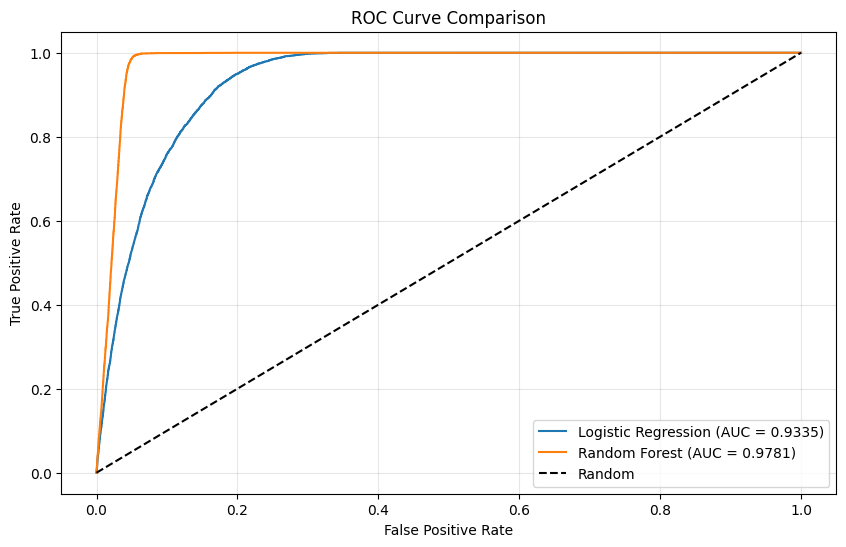

In [ ]:
#  ROC curve per la classificazione logistica
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_prob)

# ROC curve per il  Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_roc_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_roc_auc:.4f})')

# Plot random guessing line
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Principali Risultati dell'Analisi

Accuratezza Complessiva: Il modello Random Forest ha raggiunto un'elevata accuratezza di circa 0.95, superando la Regressione Logistica che ha ottenuto un punteggio di 0.84.

Punteggio ROC-AUC: Il Random Forest ha dimostrato una migliore separabilità tra le classi con un punteggio ROC-AUC di 0.98 rispetto allo 0.93 della Regressione Logistica.

La differenza più marcata risiede nella Precisione, dove il Random Forest ha ottenuto 0.66, quasi il doppio della performance della Regressione Logistica (0.35), indicando un minor numero di falsi positivi.

Il Random Forest ha raggiunto una Recall quasi perfetta (0.99), identificando efficacemente quasi tutti i casi positivi, mentre la Regressione Logistica ha avuto comunque buone prestazioni ma leggermente inferiori, fermandosi a 0.90.

F1-Score: Riflettendo l'equilibrio tra Precisione e Recall, il Random Forest ha ottenuto un F1-Score di 0.79, significativamente più alto dello 0.50 della Regressione Logistica.

Osservazioni

Insight (Osservazione): Sebbene entrambi i modelli abbiano un'alta Recall (significa che intercettano la maggior parte dei clienti rischiosi), la Regressione Logistica soffre di una Precisione molto bassa, il che significa che genera troppi "falsi allarmi". Il Random Forest riesce a mantenere un'elevata sensibilità riducendo significativamente questi falsi positivi.

Procedere con il modello Random Forest per la soluzione finale di credit scoring, in quanto offre le previsioni più affidabili e robuste.

## PUNTO BONUS

In [ ]:
#Installa e importa SHAP https://github.com/shap/shap
!pip install shap
import shap

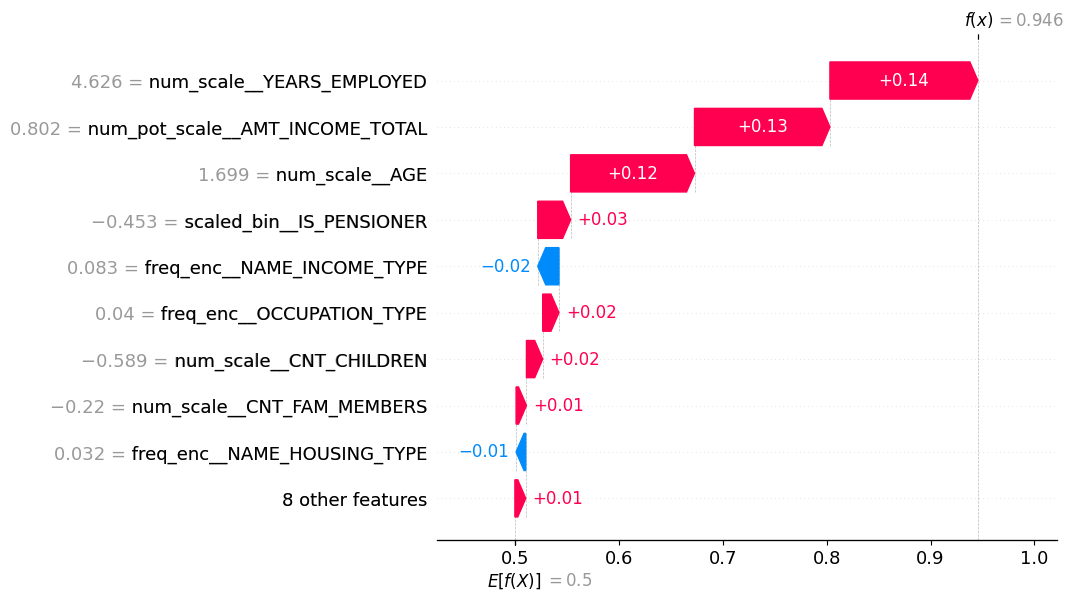

--------------------------------------------------
ANALISI CLIENTE : 5000
ID_CLIENTE: 5024492
--------------------------------------------------
Soglia di Rischio Massima:      10.00%
Probabilità di Default Calcolata: 95.42%

>>> ESITO: ❌ RIFIUTA (RISCHIO TROPPO ALTO)
--------------------------------------------------


In [ ]:
# Selezioniamo SOLO il cliente numero XXX

cliente_idx = 5000 #indice della riga del dataset di test, non rappresenta l'ID del cliente presente all'interno del dataset di partenza
dati_per_modello = X_test_transformed[cliente_idx]
vero_id_banca = df.iloc[cliente_idx]['ID']

singolo_cliente = X_test_transformed[cliente_idx].reshape(1, -1)

SOGLIA_CUTOFF = 0.10 #soglia al di sopra delle quale riteniamo un cliente troppo rischioso (impostata arbitrariamente e dipenderà poi dalle decisioni di business )

prob_rischio = rf_model.predict_proba(singolo_cliente)[0, 1]

shap_values_single = explainer.shap_values(singolo_cliente)

valori_rischio = shap_values_single[1][0] if isinstance(shap_values_single, list) else shap_values_single[0, :, 1]

# Grafico a cascata per il cliente selezionato
shap.plots.waterfall(shap.Explanation(values=valori_rischio,
                                      base_values=explainer.expected_value[1],
                                      data=singolo_cliente[0],
                                      feature_names=feature_names_out))

# STAMPA DELLA DECISIONE (ACCETTA / RIFIUTA)
print("-" * 50)
print(f"ANALISI CLIENTE : {cliente_idx}")
print(f"ID_CLIENTE: {vero_id_banca}")
print("-" * 50)

print(f"Soglia di Rischio Massima:      {SOGLIA_CUTOFF:.2%}")
print(f"Probabilità di Default Calcolata: {prob_rischio:.2%}")

if prob_rischio > SOGLIA_CUTOFF:
    print("\n>>> ESITO: ❌ RIFIUTA (RISCHIO TROPPO ALTO)")
else:
    print("\n>>> ESITO: ✅ ACCETTA (CLIENTE SICURO)")

print("-" * 50)


### Si osserva che il base value è 0.5 e questo dipende dal fatto che le classi sono state bilanciate durante l'addestramento del modello. Quindi per il modello la probabilità a priori di avere un buono o un cattivo pagatore risulta del 50%. La probabilità tirata fuori dal modello non può essere presa come probabilità assoluta ma relativa. Quindi basandoci sul valore di soglia con questa logica il modello andrà a sovrastimare in molti casi il rischio ma questo approccio risulta più prudente in quanto le perdite legate ai cattivi pagatori potrebbero risultare di diversi ordini di grandezza maggiori rispetto ai profitti generati dalla concessione della carta di credito.

###




# La versione da dare al cliente di esempio potrebbe essere la seguente:


#Motivazione della Valutazione:
Il nostro modello di analisi del rischio creditizio ha rilevato alcuni parametri che, combinati, superano la soglia di esposizione prevista per questo prodotto. Nello specifico, i fattori principali che hanno influito sulla decisione sono:

Anzianità Lavorativa: Il rapporto tra il suo reddito e la durata dell'attuale impiego risulta statisticamente meno solido rispetto ai nostri standard attuali di approvazione.

Profilo Demografico: La fascia anagrafica di appartenenza, incrociata con la tipologia di reddito, mostra nei nostri archivi una frequenza di rischio superiore alla media.